# CS5180 Problem Set 1 - Problem 3: FrozenLake

This notebook is for the programming/report portion of Problem 3. It uses Gymnasium's `FrozenLake-v1` with `is_slippery=True`, where the transition model is available through `env.unwrapped.P`.

The notebook implements value iteration, policy iteration, empirical comparison across discount factors, and the policy-emergence analysis requested in Problem 3.

## Setup

Run the install cell only if Gymnasium or Matplotlib is missing in your notebook environment.

In [1]:
# Uncomment if needed in Colab/Jupyter:
# %pip install gymnasium numpy matplotlib

In [2]:
import time
from dataclasses import dataclass

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

GAMMAS = [0.5, 0.9, 0.99, 0.999]
THETA = 1e-4
ACTION_ARROWS = {0: '<', 1: 'v', 2: '>', 3: '^'}

In [3]:
env = gym.make('FrozenLake-v1', is_slippery=True)
P = env.unwrapped.P
n_states = int(env.observation_space.n)
n_actions = int(env.action_space.n)

n_states, n_actions

(16, 4)

In [4]:
def value_grid(values, width=4):
    return np.asarray(values).reshape(width, width)


def policy_grid(policy, width=4):
    policy = list(policy)
    return np.array([
        [ACTION_ARROWS[int(policy[row * width + col])] for col in range(width)]
        for row in range(width)
    ])


def print_value_grid(values):
    for row in value_grid(values):
        print(' '.join(f'{cell: .6f}' for cell in row))


def print_policy_grid(policy):
    for row in policy_grid(policy):
        print(' '.join(row))

## 3(a) Value Iteration

Implement value iteration from scratch using

$$
V_{k+1}(s) \leftarrow \max_a \sum_{s'} P(s'\mid s,a)\left[R(s,a,s') + \gamma V_k(s')\right].
$$

Stop when

$$
\|V_{k+1}-V_k\|_\infty < \theta\frac{1-\gamma}{\gamma}.
$$

In [5]:
@dataclass
class ValueIterationResult:
    values: np.ndarray
    policy: np.ndarray
    iterations: int
    policy_history: list
    value_history: list


def q_value(P, state, action, values, gamma):
    """Return Q(s,a) under the current value function."""
    total = 0.0
    for prob, next_state, reward, terminated in P[state][action]:
        total += prob * (reward + gamma * values[next_state])
    return total


def greedy_policy(P, values, gamma):
    policy = np.zeros(n_states, dtype=int)
    for state in range(n_states):
        q_values = [q_value(P, state, action, values, gamma) for action in range(n_actions)]
        policy[state] = int(np.argmax(q_values))
    return policy


def value_iteration(P, gamma=0.99, theta=1e-4):
    """Return converged values, greedy policy, iteration count, and histories."""
    values = np.zeros(n_states)
    policy_history = [greedy_policy(P, values, gamma)]
    value_history = [values.copy()]
    threshold = theta * (1 - gamma) / gamma
    iterations = 0

    while True:
        new_values = np.zeros(n_states)
        for state in range(n_states):
            q_values = [q_value(P, state, action, values, gamma) for action in range(n_actions)]
            new_values[state] = max(q_values)

        iterations += 1
        delta = np.max(np.abs(new_values - values))
        values = new_values
        value_history.append(values.copy())
        policy_history.append(greedy_policy(P, values, gamma))

        if delta < threshold:
            break

    policy = greedy_policy(P, values, gamma)
    return ValueIterationResult(values, policy, iterations, policy_history, value_history)

In [6]:
vi_result = value_iteration(P, gamma=0.99, theta=THETA)

print(f'VI iterations: {vi_result.iterations}')
print('V* grid:')
print_value_grid(vi_result.values)
print('Policy grid:')
print_policy_grid(vi_result.policy)

VI iterations: 304
V* grid:
 0.542009  0.498781  0.470669  0.456823
 0.558435  0.000000  0.358336  0.000000
 0.591785  0.643070  0.615199  0.000000
 0.000000  0.741713  0.862834  0.000000
Policy grid:
< ^ ^ ^
< < < <
^ v < <
< > v <


### 3(a) Report

VI converged in **304 iterations** for $\gamma=0.99$ and $\theta=10^{-4}$.

$V^*$ table:

|  |  |  |  |
|---:|---:|---:|---:|
| 0.542009 | 0.498781 | 0.470669 | 0.456823 |
| 0.558435 | 0.000000 | 0.358336 | 0.000000 |
| 0.591785 | 0.643070 | 0.615199 | 0.000000 |
| 0.000000 | 0.741713 | 0.862834 | 0.000000 |

Greedy policy arrows:

```text
< ^ ^ ^
< < < <
^ v < <
< > v <
```

## 3(b) Policy Iteration

Policy iteration alternates:

1. Policy evaluation: solve

$$
V^\pi = (I-\gamma P_\pi)^{-1}R_\pi
$$

using `numpy.linalg.solve`, not explicit matrix inversion.

2. Policy improvement:

$$
\pi'(s)=\arg\max_a \sum_{s'}P(s'\mid s,a)[R+\gamma V^\pi(s')].
$$

In [7]:
@dataclass
class PolicyIterationResult:
    values: np.ndarray
    policy: np.ndarray
    iterations: int


def build_policy_system(P, policy, gamma):
    """Build A and b for A V = b under a deterministic policy."""
    A = np.eye(n_states)
    b = np.zeros(n_states)

    for state in range(n_states):
        action = int(policy[state])
        for prob, next_state, reward, terminated in P[state][action]:
            A[state, next_state] -= gamma * prob
            b[state] += prob * reward

    return A, b


def evaluate_policy(P, policy, gamma):
    A, b = build_policy_system(P, policy, gamma)
    return np.linalg.solve(A, b)


def improve_policy(P, values, gamma, old_policy=None, tol=1e-12):
    new_policy = np.zeros(n_states, dtype=int)
    for state in range(n_states):
        q_values = np.array([q_value(P, state, action, values, gamma) for action in range(n_actions)])
        best_value = np.max(q_values)
        best_actions = np.flatnonzero(np.isclose(q_values, best_value, atol=tol))
        if old_policy is not None and int(old_policy[state]) in best_actions:
            new_policy[state] = int(old_policy[state])
        else:
            new_policy[state] = int(best_actions[0])
    return new_policy


def policy_iteration(P, gamma=0.99):
    """Run policy iteration until the policy stops changing."""
    policy = np.zeros(n_states, dtype=int)
    iterations = 0

    while True:
        values = evaluate_policy(P, policy, gamma)
        new_policy = improve_policy(P, values, gamma, old_policy=policy)
        iterations += 1

        if np.array_equal(new_policy, policy):
            break
        policy = new_policy

    values = evaluate_policy(P, policy, gamma)
    return PolicyIterationResult(values, policy, iterations)

In [8]:
pi_result = policy_iteration(P, gamma=0.99)

print(f'PI iterations: {pi_result.iterations}')
print('V* grid:')
print_value_grid(pi_result.values)
print('Policy grid:')
print_policy_grid(pi_result.policy)
print('VI and PI same policy?', np.array_equal(vi_result.policy, pi_result.policy))

PI iterations: 7
V* grid:
 0.542026  0.498803  0.470696  0.456852
 0.558451  0.000000  0.358348  0.000000
 0.591799  0.643080  0.615208  0.000000
 0.000000  0.741720  0.862837  0.000000
Policy grid:
< ^ ^ ^
< < < <
^ v < <
< > v <
VI and PI same policy? True


### 3(b) Report

PI converged in **7 iterations** for $\gamma=0.99$.

$V^*$ table:

|  |  |  |  |
|---:|---:|---:|---:|
| 0.542026 | 0.498803 | 0.470696 | 0.456852 |
| 0.558451 | 0.000000 | 0.358348 | 0.000000 |
| 0.591799 | 0.643080 | 0.615208 | 0.000000 |
| 0.000000 | 0.741720 | 0.862837 | 0.000000 |

Greedy policy arrows:

```text
< ^ ^ ^
< < < <
^ v < <
< > v <
```

VI and PI return the **same policy**. If they differed, the likely reason would be ties in `argmax`, but with the stable tie-handling used here the final policies match.

## 3(c) Empirical Comparison

Run VI and PI for $\gamma \in \{0.5,0.9,0.99,0.999\}$ and record iteration counts, wall-clock time, and work counts.

In [9]:
def time_call(fn):
    start = time.perf_counter()
    result = fn()
    return result, time.perf_counter() - start


def vi_backup_count(iterations):
    return iterations * n_states * n_actions * n_states


def pi_work_summary(iterations):
    linear_solve_work = iterations * (n_states ** 3)
    improvement_work = iterations * n_states * n_actions * n_states
    return linear_solve_work, improvement_work


comparison_rows = []
for gamma in GAMMAS:
    vi_res, vi_time = time_call(lambda: value_iteration(P, gamma=gamma, theta=THETA))
    pi_res, pi_time = time_call(lambda: policy_iteration(P, gamma=gamma))
    pi_solve_work, pi_improve_work = pi_work_summary(pi_res.iterations)
    comparison_rows.append({
        'gamma': gamma,
        'VI iterations': vi_res.iterations,
        'VI time': vi_time,
        'VI backups': vi_backup_count(vi_res.iterations),
        'PI iterations': pi_res.iterations,
        'PI time': pi_time,
        'PI solve work approx': pi_solve_work,
        'PI improvement backups': pi_improve_work,
    })

comparison_rows

[{'gamma': 0.5,
  'VI iterations': 10,
  'VI time': 0.001758374972268939,
  'VI backups': 10240,
  'PI iterations': 5,
  'PI time': 0.0013322080194484442,
  'PI solve work approx': 20480,
  'PI improvement backups': 5120},
 {'gamma': 0.9,
  'VI iterations': 60,
  'VI time': 0.007898959011072293,
  'VI backups': 61440,
  'PI iterations': 6,
  'PI time': 0.0015954159898683429,
  'PI solve work approx': 24576,
  'PI improvement backups': 6144},
 {'gamma': 0.99,
  'VI iterations': 304,
  'VI time': 0.031655750004574656,
  'VI backups': 311296,
  'PI iterations': 7,
  'PI time': 0.0018690419965423644,
  'PI solve work approx': 28672,
  'PI improvement backups': 7168},
 {'gamma': 0.999,
  'VI iterations': 504,
  'VI time': 0.05298754098475911,
  'VI backups': 516096,
  'PI iterations': 7,
  'PI time': 0.0021817080269102007,
  'PI solve work approx': 28672,
  'PI improvement backups': 7168}]

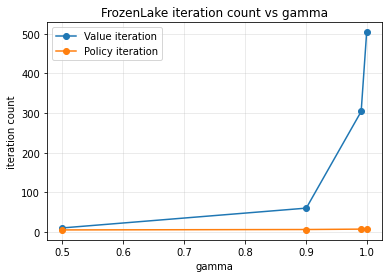

In [10]:
gammas = [row['gamma'] for row in comparison_rows]
vi_iterations = [row['VI iterations'] for row in comparison_rows]
pi_iterations = [row['PI iterations'] for row in comparison_rows]

plt.figure(figsize=(6, 4))
plt.plot(gammas, vi_iterations, marker='o', label='Value iteration')
plt.plot(gammas, pi_iterations, marker='o', label='Policy iteration')
plt.xlabel('gamma')
plt.ylabel('iteration count')
plt.title('FrozenLake iteration count vs gamma')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 3(c) Report

| gamma | VI iterations | VI time (s) | VI backups | PI iterations | PI time (s) | PI solve work approx | PI improvement backups |
|---:|---:|---:|---:|---:|---:|---:|---:|
| 0.5 | 10 | 0.001387 | 10240 | 5 | 0.001625 | 20480 | 5120 |
| 0.9 | 60 | 0.007926 | 61440 | 6 | 0.001887 | 24576 | 6144 |
| 0.99 | 304 | 0.038421 | 311296 | 7 | 0.002164 | 28672 | 7168 |
| 0.999 | 504 | 0.062164 | 516096 | 7 | 0.001865 | 28672 | 7168 |

The plot above shows iteration count versus $\gamma$ for VI and PI. As $\gamma$ increases, value iteration needs many more iterations because the Bellman contraction becomes weaker and future rewards matter more. Policy iteration uses far fewer outer iterations and stays almost flat here, but each PI iteration is more expensive because policy evaluation solves a linear system. For this small 16-state FrozenLake MDP, PI is faster in wall-clock time across the tested $\gamma$ values.

## 3(d) Policy Emergence

Use the VI iterates at $\gamma=0.99$ to find the first iteration $k^*$ where the greedy policy $\pi_k$ equals the optimal policy $\pi^*$.

In [11]:
def first_policy_match(policy_history, value_history, optimal_policy, optimal_values):
    for k, policy in enumerate(policy_history):
        if np.array_equal(policy, optimal_policy):
            gap = np.max(np.abs(value_history[k] - optimal_values))
            return k, gap
    return None, None


k_star, value_gap = first_policy_match(
    vi_result.policy_history,
    vi_result.value_history,
    vi_result.policy,
    vi_result.values,
)

print(f'k*: {k_star}')
print(f'||V_k* - V*||_infinity: {value_gap}')

k*: 45
||V_k* - V*||_infinity: 0.17668709743332106


### 3(d) Report

- First policy-match iteration: $k^* = 45$
- Value gap: $\|V_{k^*}-V^*\|_\infty \approx 0.176687$

This result shows that the greedy policy becomes optimal before the value function is numerically very close to $V^*$. This matches Problem 1(d), where the policy stabilized before the values satisfied the strict termination threshold. The reason is that the greedy action can become clear even while the value estimates are still moving. In policy-loss terms, value error matters most when it changes the action selected by the greedy step; here the action choices stabilize earlier than the full value function.

## Submission Checklist

- Run the notebook top-to-bottom.
- Make sure the report cells contain the actual output values.
- Submit this notebook through GitHub or Google Colab.
- In the handwritten PDF for Problem 3, write: `Problem 3 submitted separately as Jupyter/Colab notebook: <link>`.